<a href="https://colab.research.google.com/github/RyanLiuQc/EEG-model/blob/main/EEG_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 32.1 MB/s eta 0:00:00


In [4]:
# Install AWS CLI
!pip install awscli --quiet

# Sync subject 01 data from the public S3 bucket
!aws s3 sync --no-sign-request s3://physionet-open/chbmit/1.0.0/chb01/ ./chbmit_data/chb01/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://physionet-open/chbmit/1.0.0/chb01/chb01-summary.txt to chbmit_data/chb01/chb01-summary.txt
download: s3://physionet-open/chbmit/1.0.0/chb01/chb01_03.edf.seizures to chbmit_data/chb01/chb01_03.edf.seizures
download: s3://physionet-open/chbmit/1.0.0/chb01/chb01_04.edf.seizures to chbmit_data/chb01/chb01_04.edf.seizures
download: s3://physionet-open/chbmit/1.0.0/chb01/chb01_01.edf to chbmit_data/chb01

In [9]:
import mne
import numpy as np



In [32]:
# Load the raw EDF file; preload=True loads data into memory for faster processing
# loading only the 2nd patient's data: chb01_02
raw = mne.io.read_raw_edf("/content/chbmit_data/chb01/chb01_02.edf", preload=True)

Extracting EDF parameters from /content/chbmit_data/chb01/chb01_02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_671/3758860363.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf("/content/chbmit_data/chb01/chb01_02.edf", preload=True)


In [33]:
print(raw.info)
print(raw)

<Info | 8 non-empty values
 bads: []
 ch_names: FP1-F7, F7-T7, T7-P7, P7-O1, FP1-F3, F3-C3, C3-P3, P3-O1, ...
 chs: 23 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 2076-11-06 12:42:57 UTC
 nchan: 23
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Surrogate>
>
<RawEDF | chb01_02.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_671/3028553045.py:1: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)


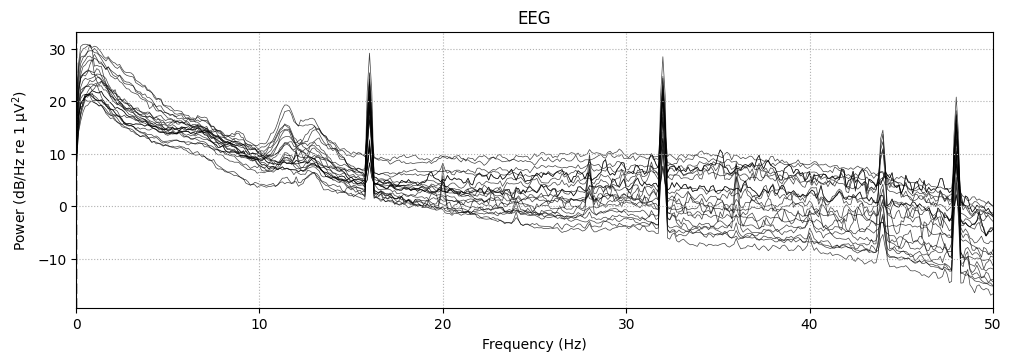

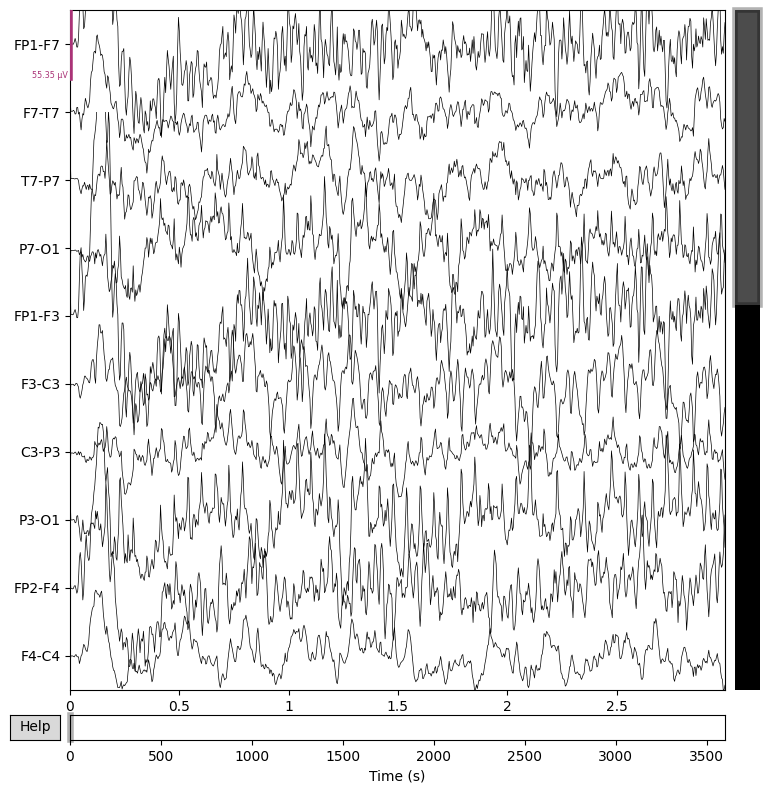

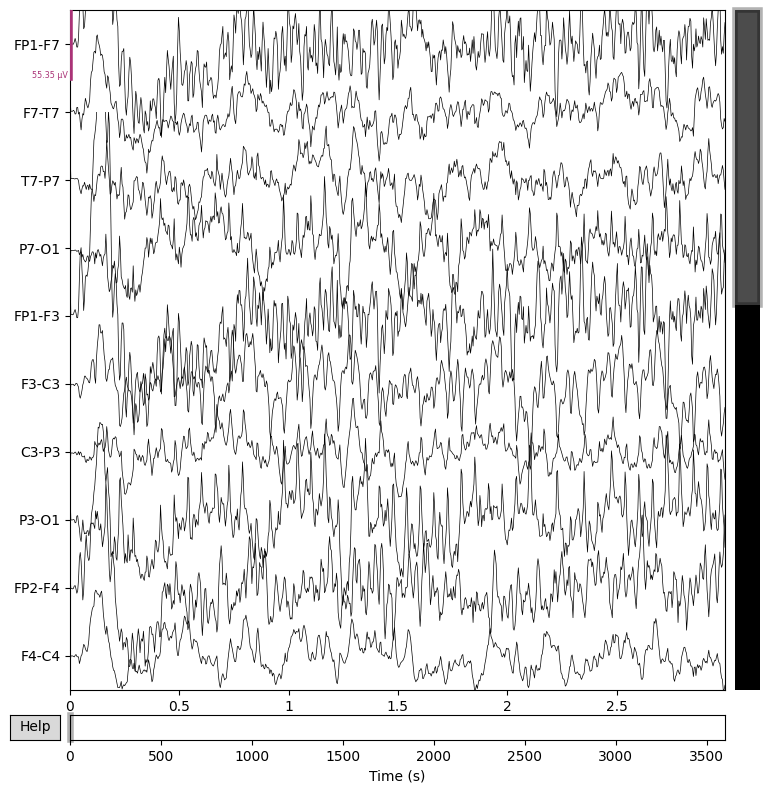

In [34]:
raw.compute_psd(fmax=50).plot(picks="data", exclude="bads", amplitude=False)
raw.plot(duration=3, n_channels=10, scalings='auto', remove_dc=True, title="Raw EEG Data - chb01_02 (Fixed Scale)")